In [2]:
import os
import numpy as np

filter_folder = r"D:\Users\Abigail Crowther\Desktop\Uni\Year 4\MPhys Projects\Semester 2 - Star Formation Histories\star-formation-histories\Data\starburst_filters"

global_min = np.inf
global_max = -np.inf

for fname in os.listdir(filter_folder):
    if fname.endswith(".txt"):

        filepath = os.path.join(filter_folder, fname)
        data = np.loadtxt(filepath)

        lam_min = data[:, 0].min()
        lam_max = data[:, 0].max()

        global_min = min(global_min, lam_min)
        global_max = max(global_max, lam_max)

        print(f"{fname:20s}  {lam_min:.0f} – {lam_max:.0f} Å")

print("\nOverall wavelength coverage:")
print(f"{global_min:.0f} – {global_max:.0f} Å")


HST_ACS_WFC_F435W.txt  3526 – 4979 Å
HST_ACS_WFC_F606W.txt  4569 – 7283 Å
HST_ACS_WFC_F814W.txt  6738 – 9778 Å
HST_WFC3_IR_F105W.txt  8650 – 12250 Å
HST_WFC3_IR_F125W.txt  10640 – 14390 Å
HST_WFC3_IR_F140W.txt  11370 – 16450 Å
HST_WFC3_IR_F160W.txt  13664 – 17205 Å
JWST_NIRCam_F090W.txt  7836 – 10356 Å
JWST_NIRCam_F115W.txt  9892 – 13282 Å
JWST_NIRCam_F150W.txt  12798 – 17238 Å
JWST_NIRCam_F200W.txt  16904 – 22984 Å
JWST_NIRCam_F277W.txt  23371 – 33015 Å
JWST_NIRCam_F356W.txt  29930 – 42294 Å
JWST_NIRCam_F410M.txt  36740 – 45226 Å
JWST_NIRCam_F444W.txt  37132 – 50996 Å

Overall wavelength coverage:
3526 – 50996 Å


In [3]:
import os
import numpy as np

filter_folder = r"D:\Users\Abigail Crowther\Desktop\Uni\Year 4\MPhys Projects\Semester 2 - Star Formation Histories\star-formation-histories\Data\starburst_filters"

filter_files = [
    os.path.join(filter_folder, f)
    for f in os.listdir(filter_folder)
    if f.endswith(".txt")
]

filter_files.sort()

print(filter_files)


['D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star Formation Histories\\star-formation-histories\\Data\\starburst_filters\\HST_ACS_WFC_F435W.txt', 'D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star Formation Histories\\star-formation-histories\\Data\\starburst_filters\\HST_ACS_WFC_F606W.txt', 'D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star Formation Histories\\star-formation-histories\\Data\\starburst_filters\\HST_ACS_WFC_F814W.txt', 'D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star Formation Histories\\star-formation-histories\\Data\\starburst_filters\\HST_WFC3_IR_F105W.txt', 'D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star Formation Histories\\star-formation-histories\\Data\\starburst_filters\\HST_WFC3_IR_F125W.txt', 'D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star For

In [4]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

ages_myr_1 = np.arange(0,110,10)
ages_myr_2 = np.arange(200, 1100, 100)

ages_gyr = np.concatenate([ages_myr_1, ages_myr_2]) / 1000

Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sampler instead.


In [5]:
dust = {}
dust["type"] = "Calzetti"
dust["Av"] = 0.2
dust["eta"] = 2. #multiplies Av - extra dust for young stars

nebular = {}   #nebular emission component
nebular["logU"] = -3.   #log_10(ionization parameter)

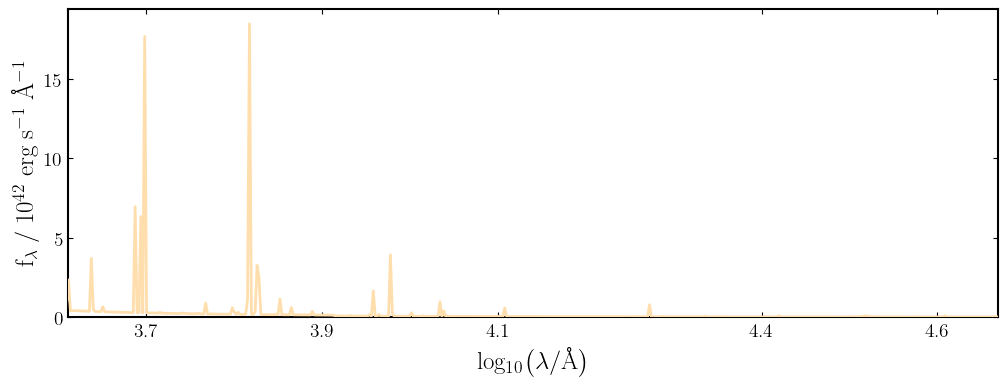

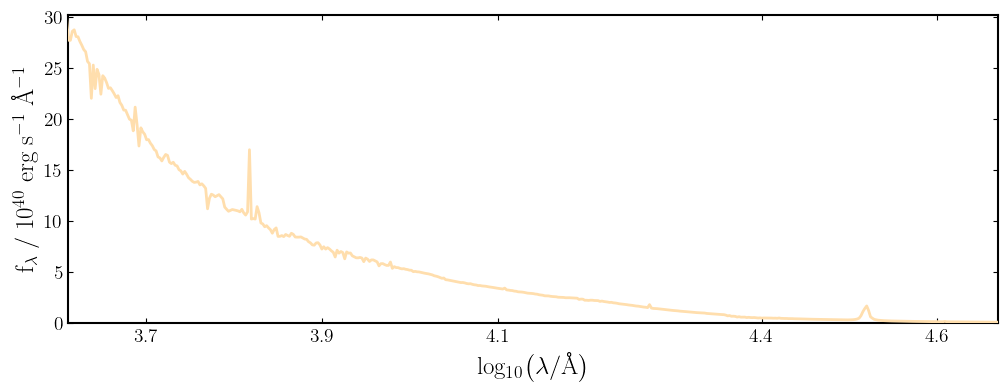

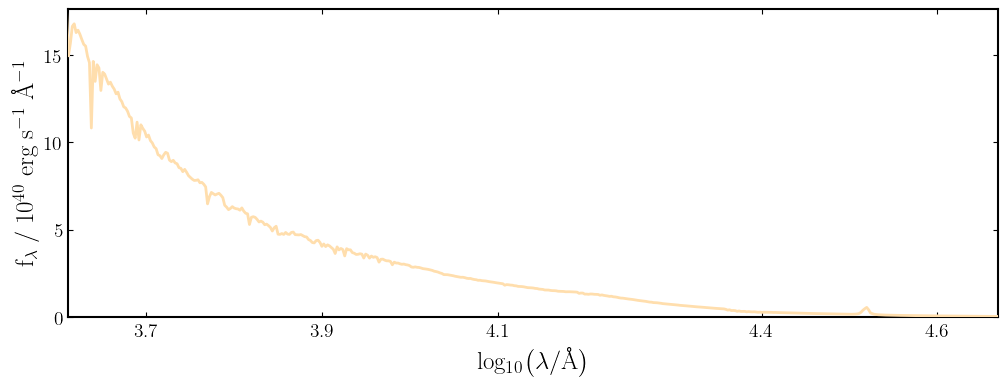

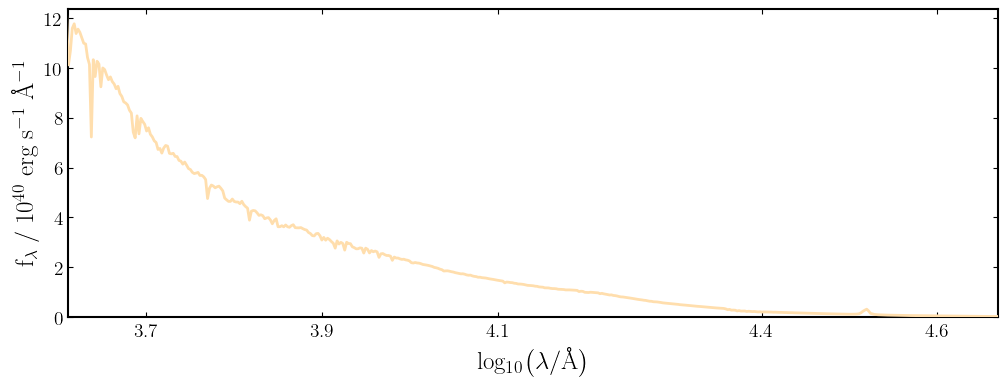

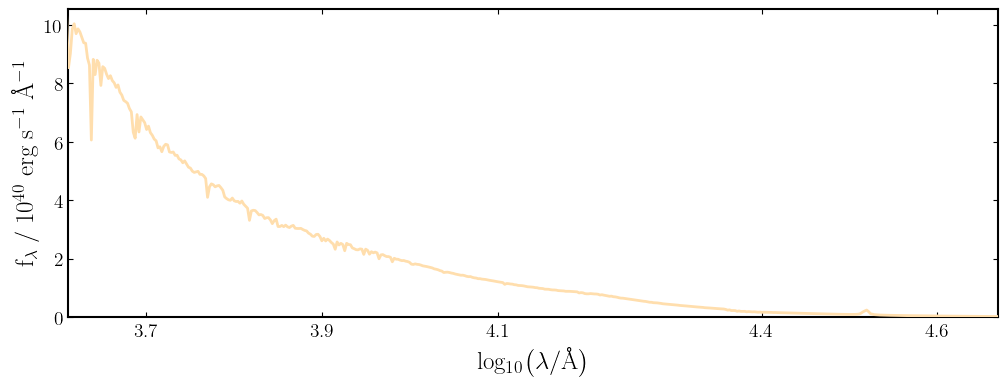

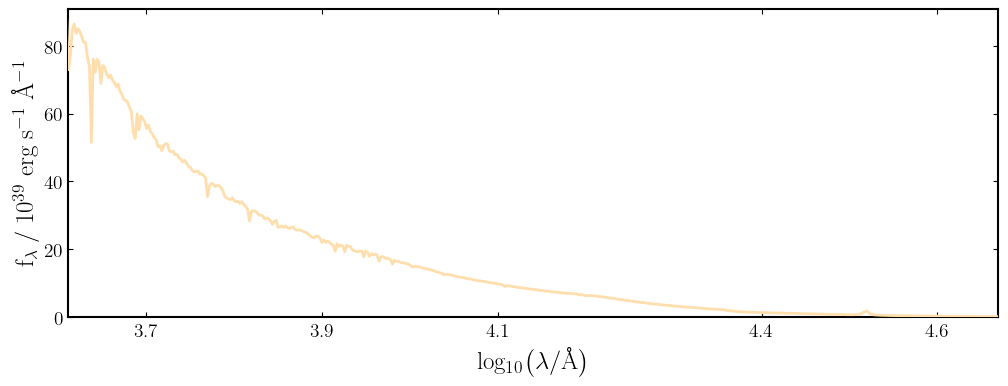

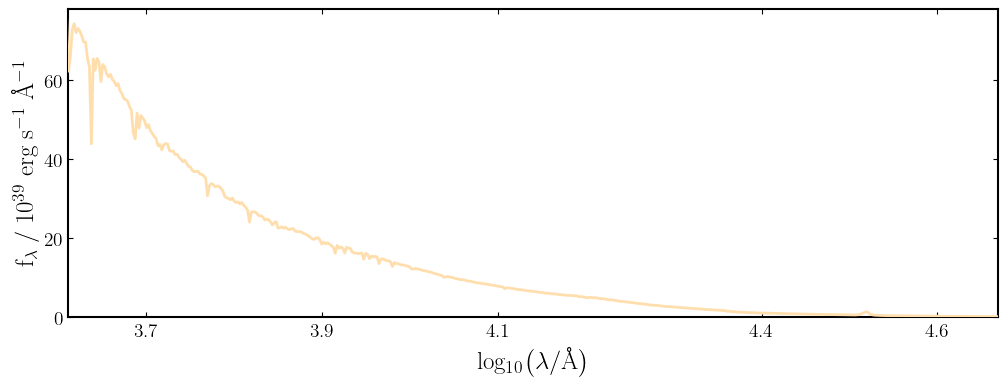

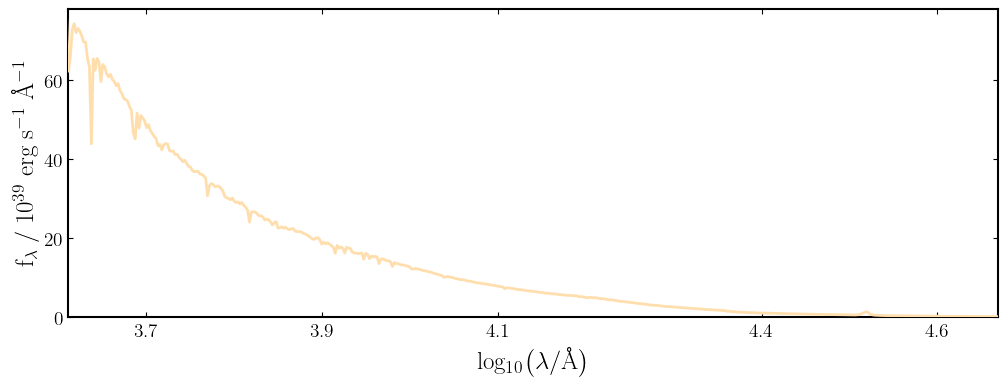

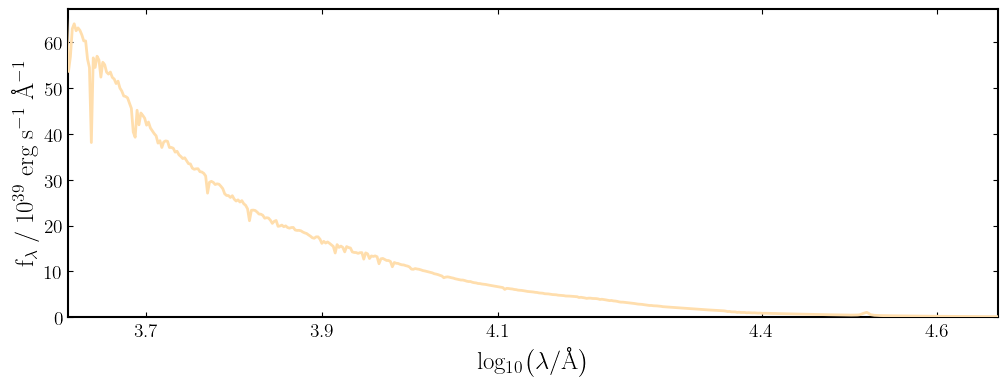

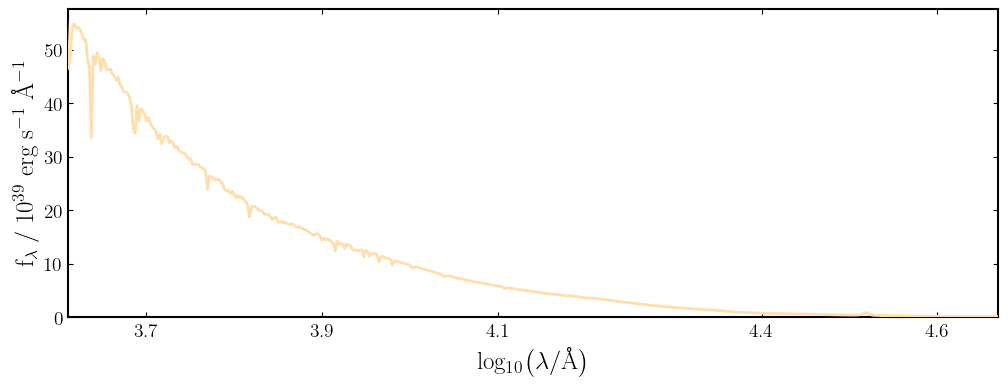

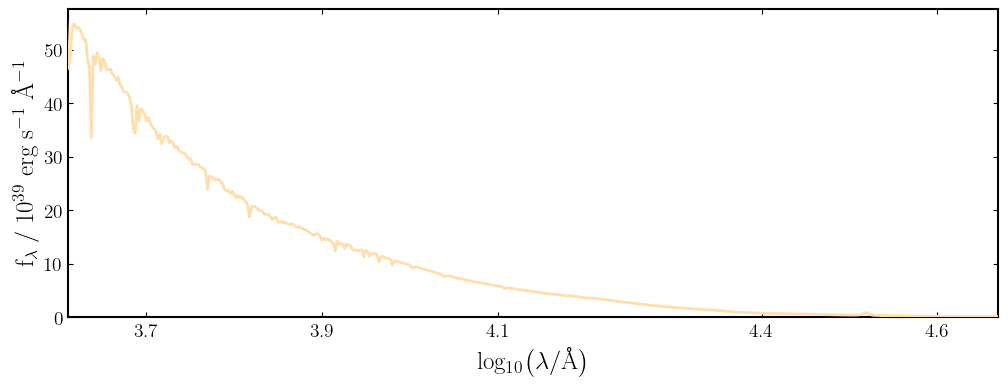

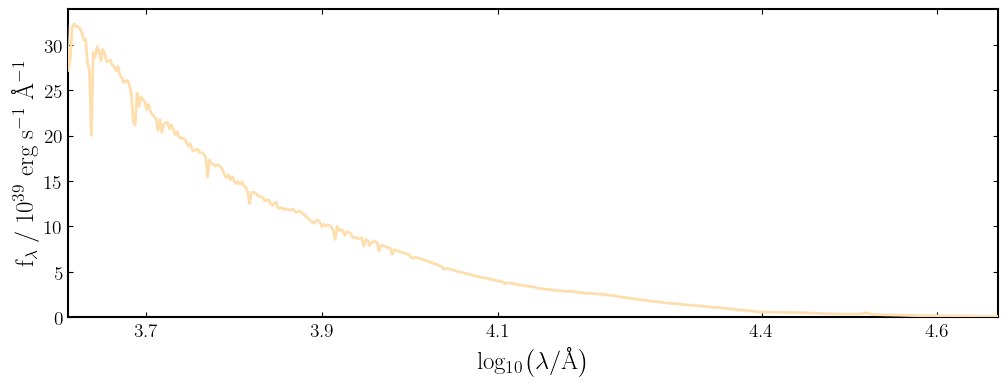

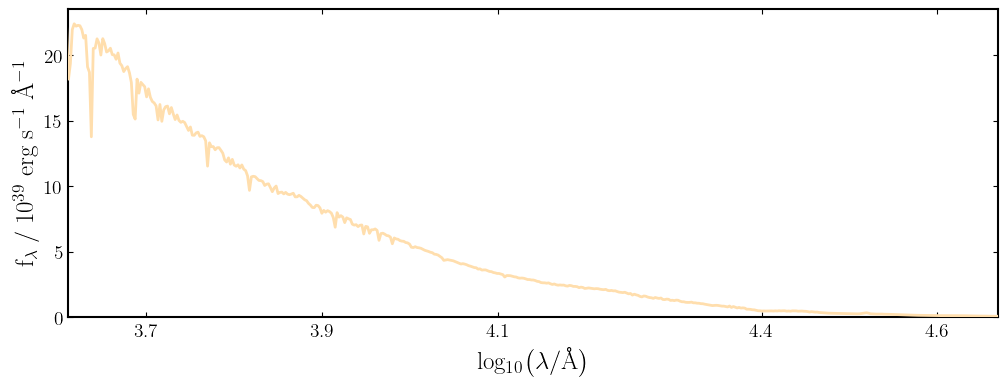

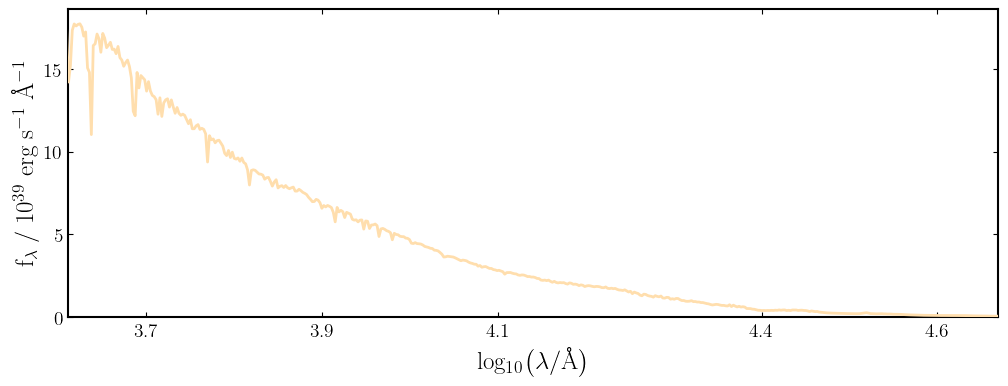

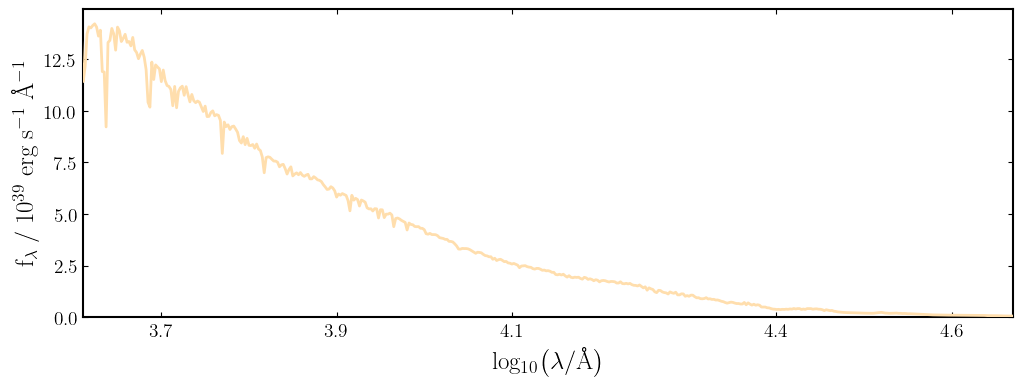

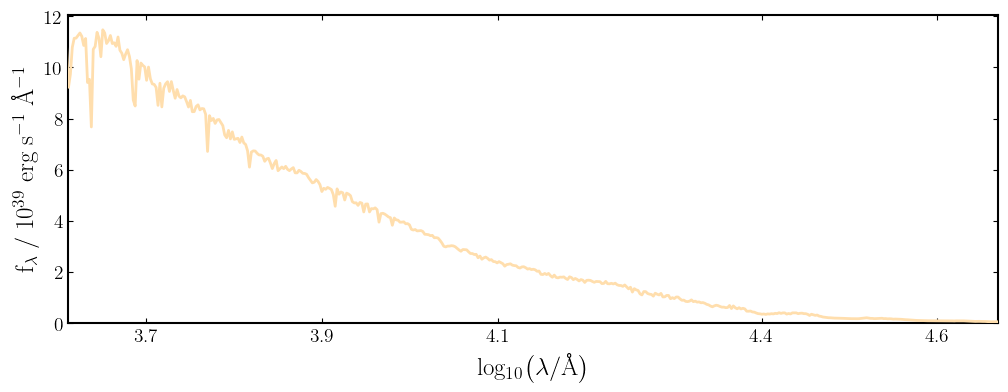

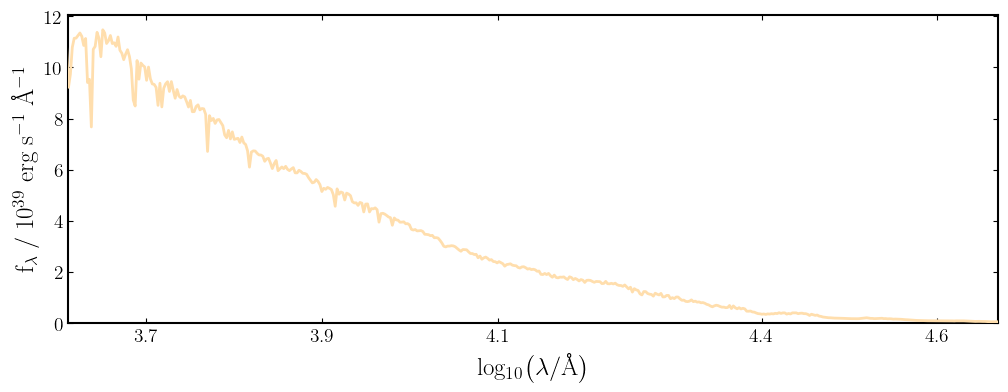

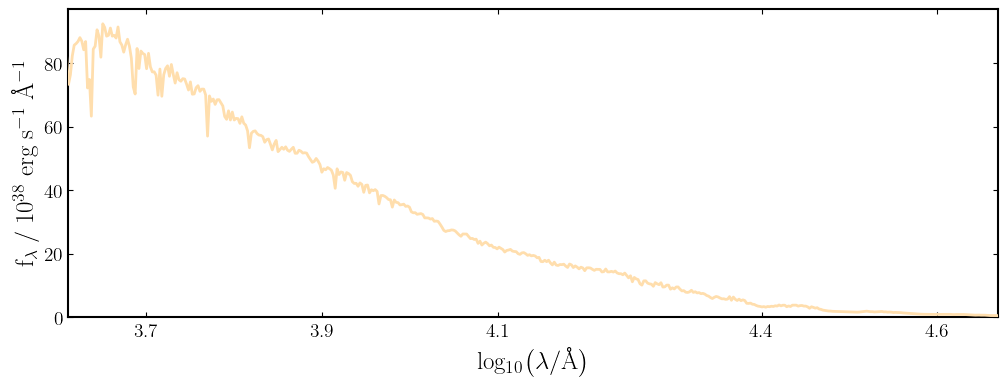

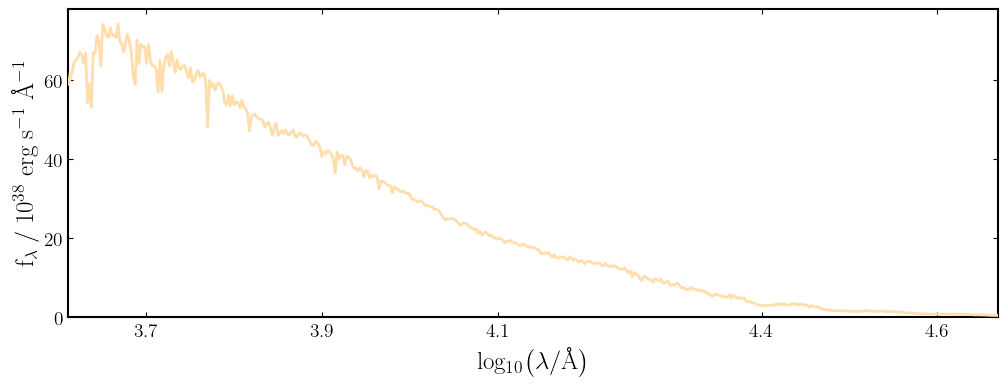

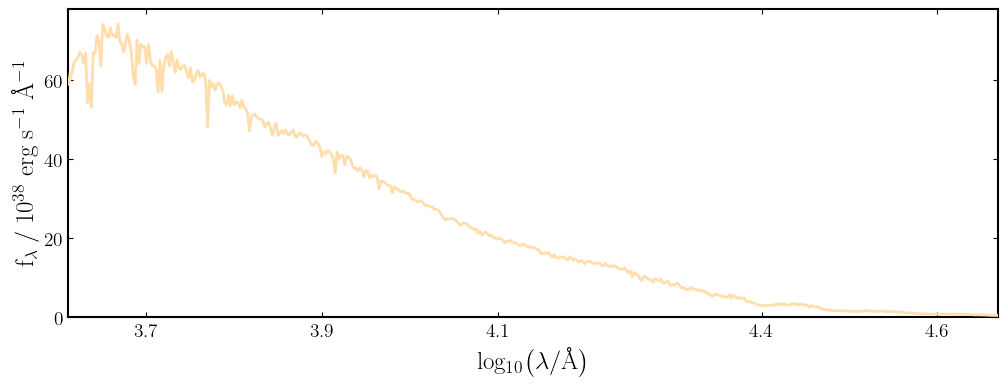

In [7]:
for age in ages_gyr:

    burst = {
        "age": age,           #Gyr before observation
        "massformed": 10,     #log10(M*/Msun)
        "metallicity": 0.5
    }

    model_components = {
        "redshift": 0,
        "burst": burst,
        "dust": dust,
        "nebular": nebular,
        "veldisp": 200.,      #km/s
        "t_bc": 0.01       #lifetime of birth clouds (Gyr)
    }

    model = pipes.model_galaxy(
        model_components,
        filt_list=filter_files, spec_units='mujy', phot_units='mujy'
    )

    #plot spectrum
    fig, ax = model.plot()

    plt.show()
    plt.close(fig)


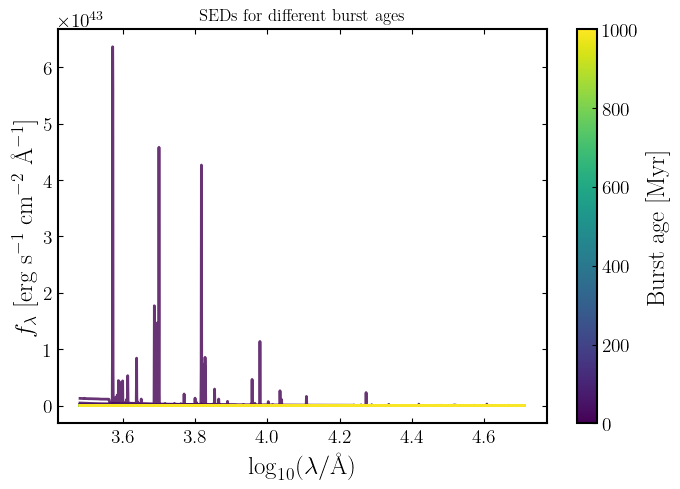

In [9]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

os.environ["PATH"] += r";C:\Users\Abigail Crowther\AppData\Local\Programs\MiKTeX\miktex\bin\x64"

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{amssymb}"
})

years = np.concatenate([
    np.arange(0, 110, 10),
    np.arange(100, 1100, 100)
])

fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

for t in years:

    burst = {
        "age": t / 1000.,     # convert Myr → Gyr
        "massformed": 10,
        "metallicity": 0.5
    }

    model_components = {
        "redshift": 0,
        "burst": burst,
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,
        "veldisp": 200.
    }
    model = pipes.model_galaxy(
        model_components,
        filt_list=filter_files,
       spec_wavs = np.arange(global_min - 500,
                      global_max + 500,
                      5.)

    )

    ax.plot(
        np.log10(model.spec_wavs),  # log10(lambda / Å)
        model.spectrum,             # f_lambda [erg s^-1 cm^-2 Å^-1]
        color=cmap(norm(t)),
        alpha=0.8
    )

ax.set_xlabel(r"$\log_{10}(\lambda / \mathrm{\AA})$")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]")
ax.set_title("SEDs for different burst ages")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()

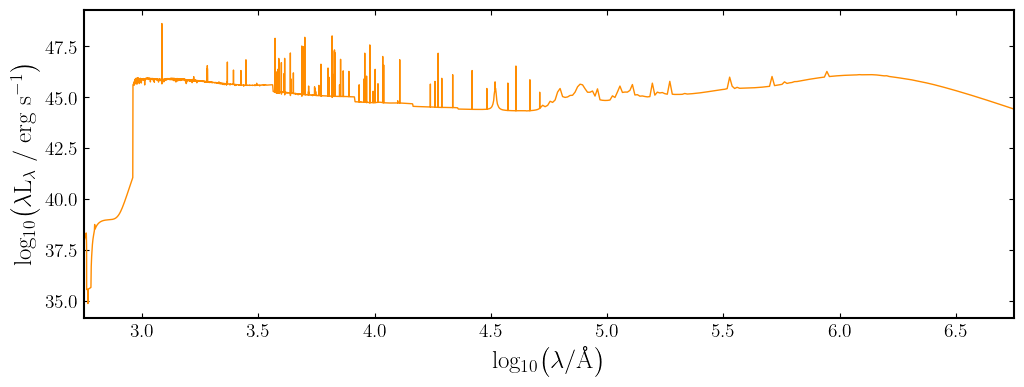

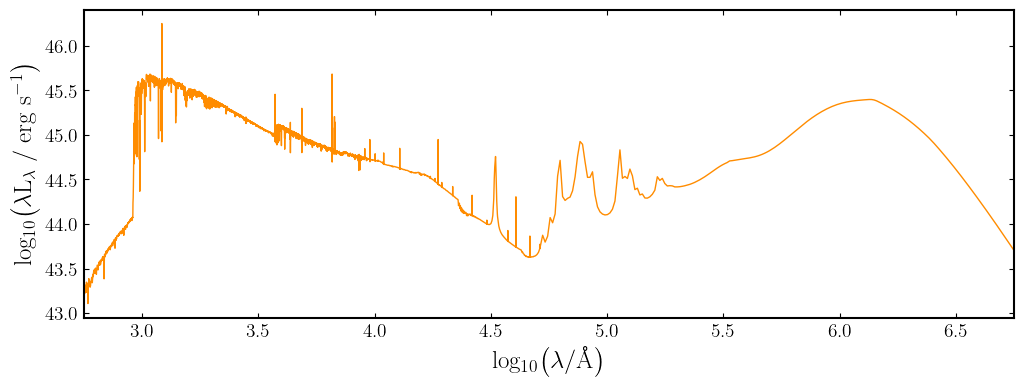

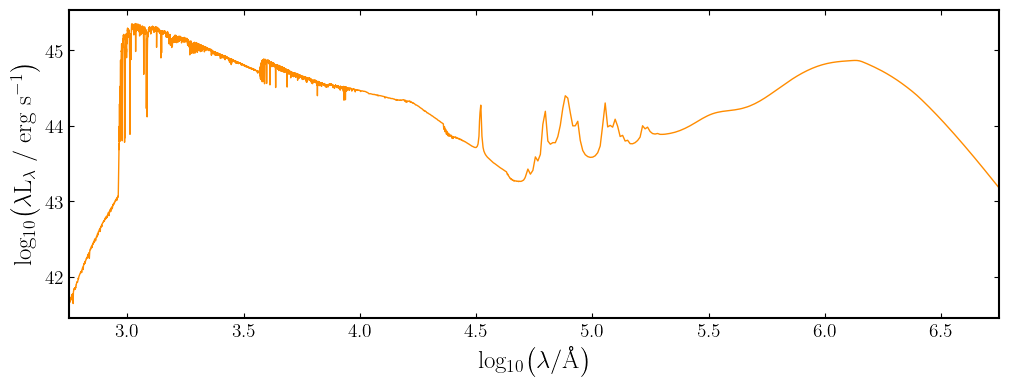

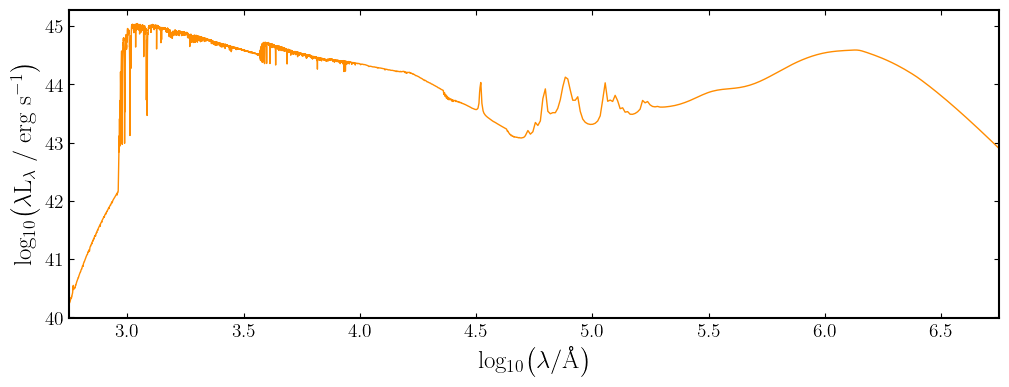

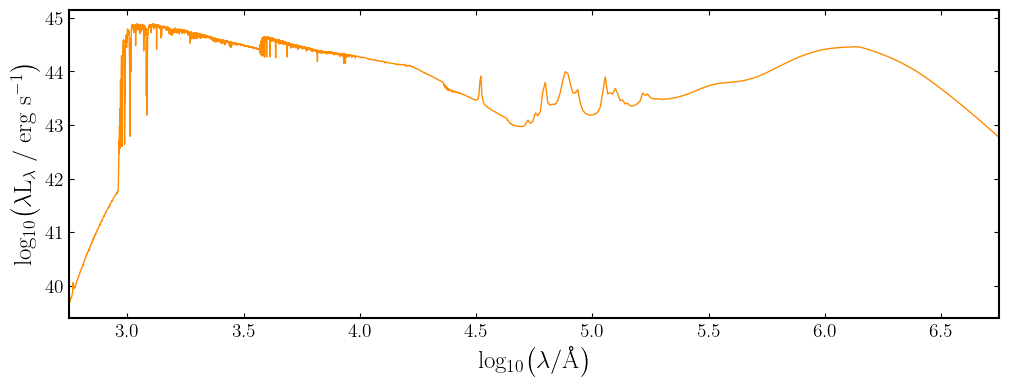

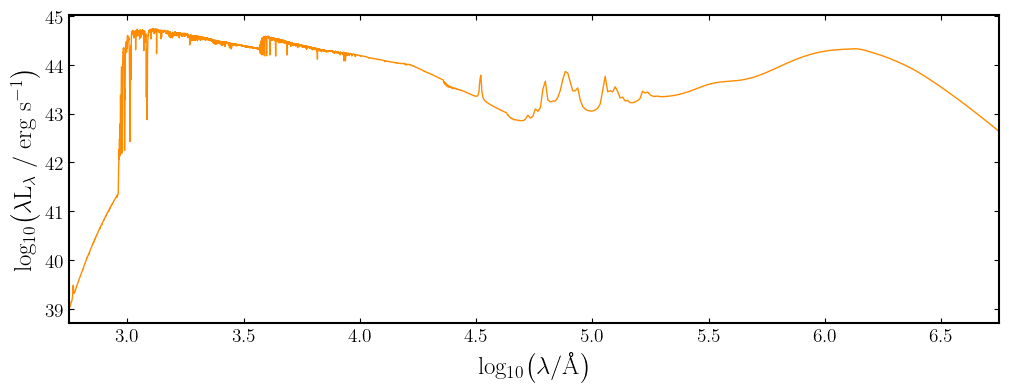

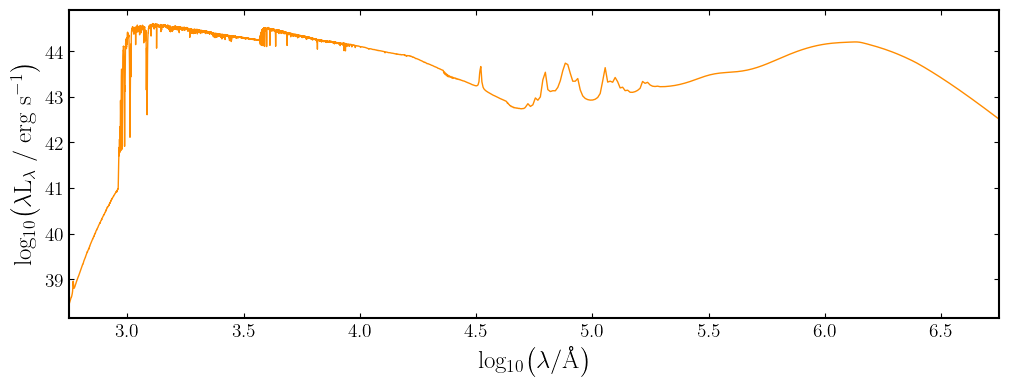

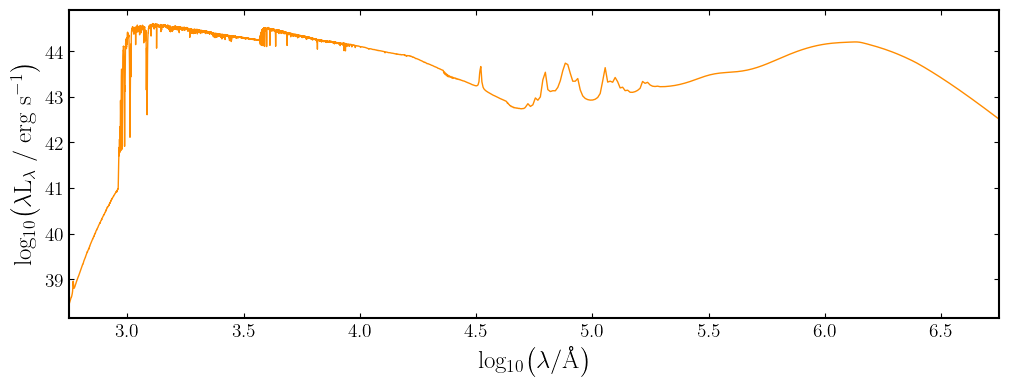

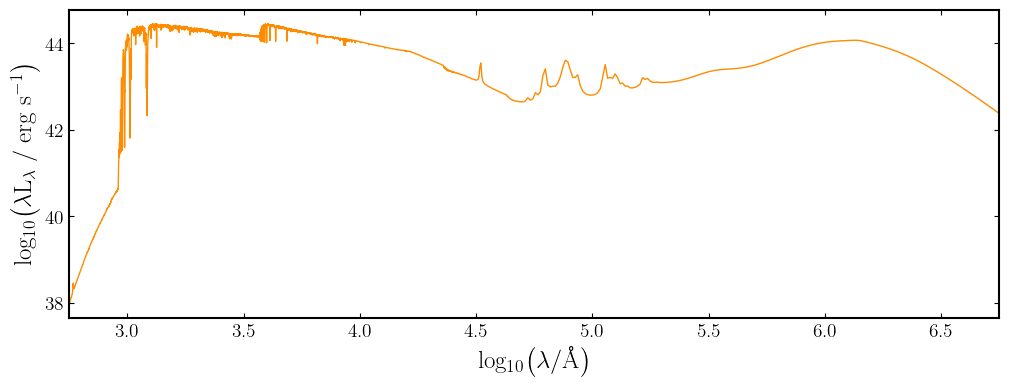

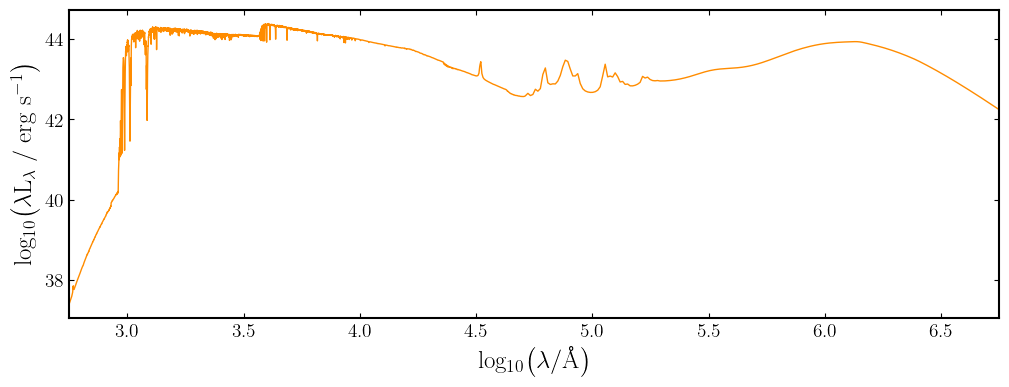

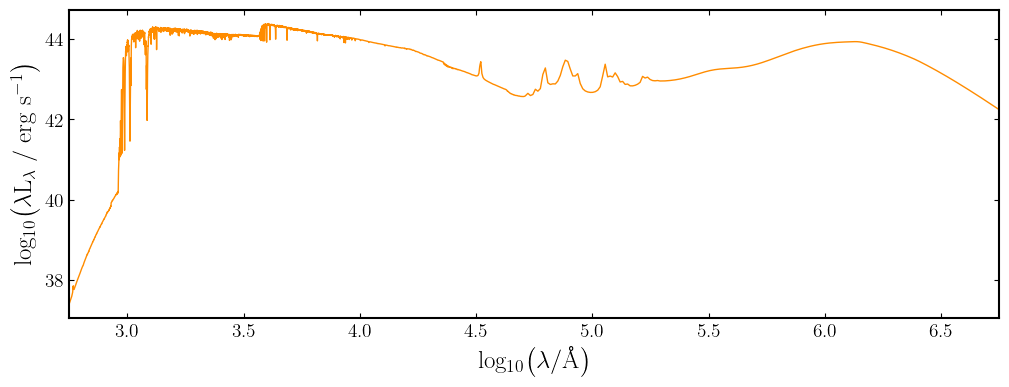

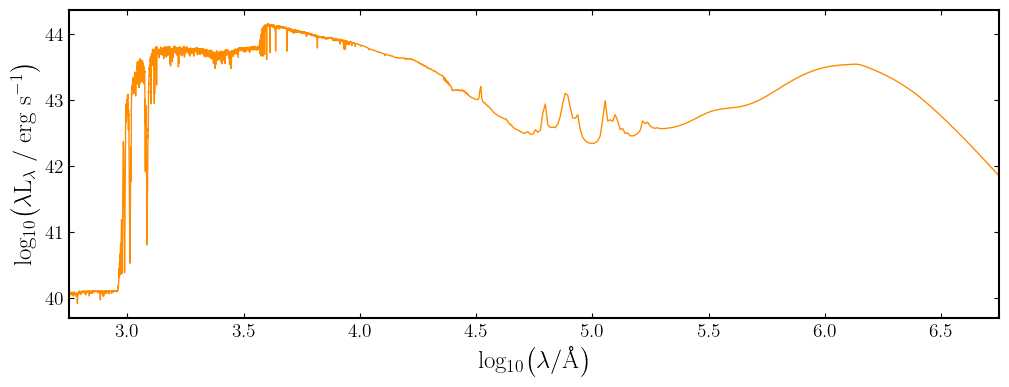

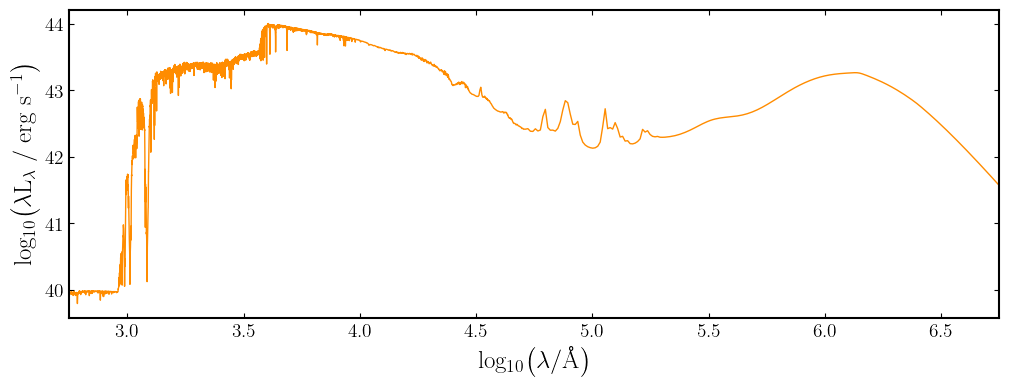

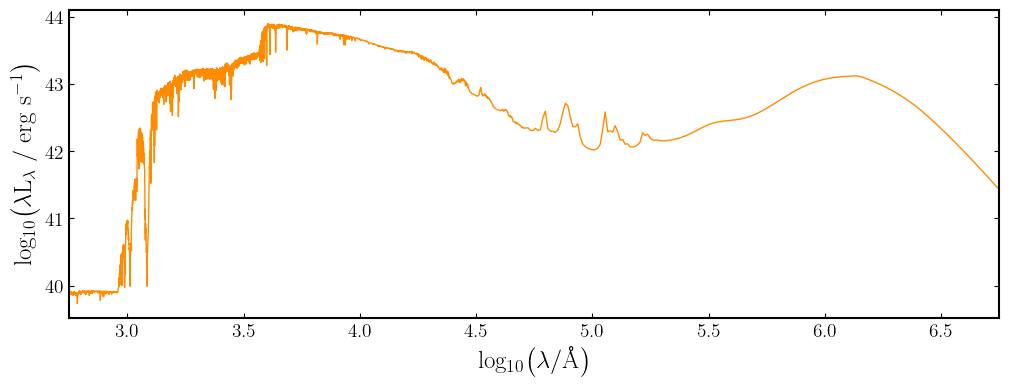

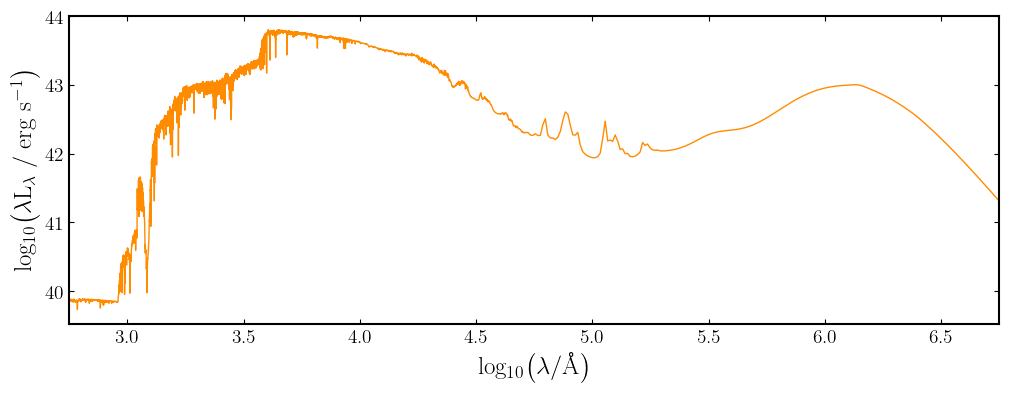

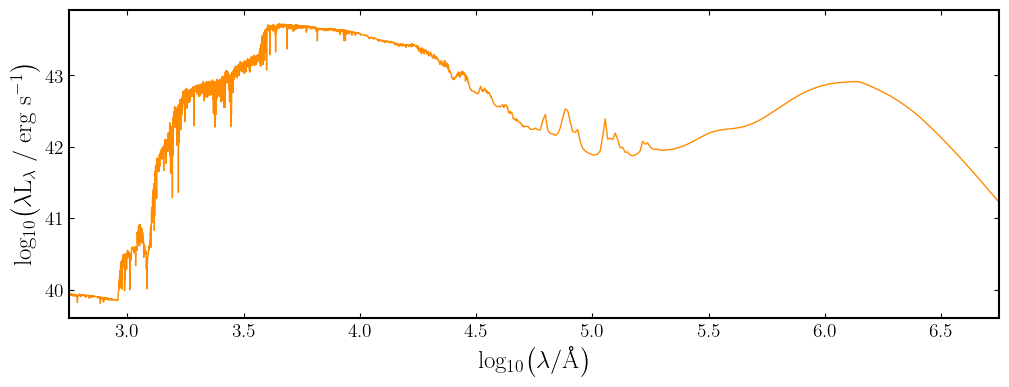

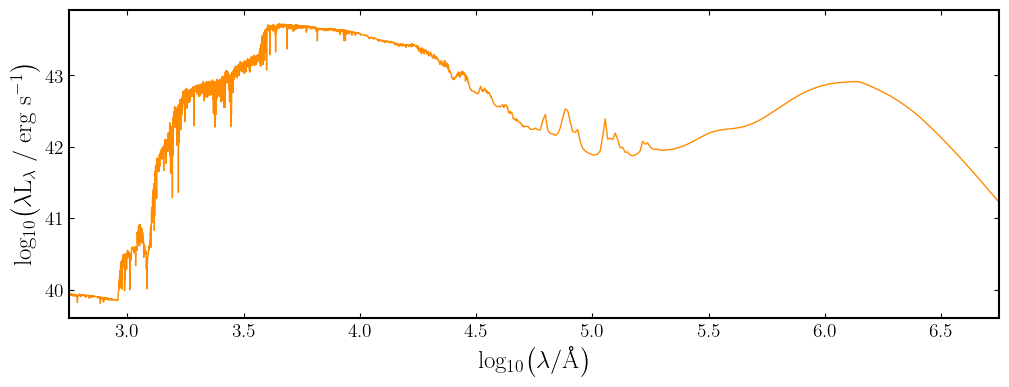

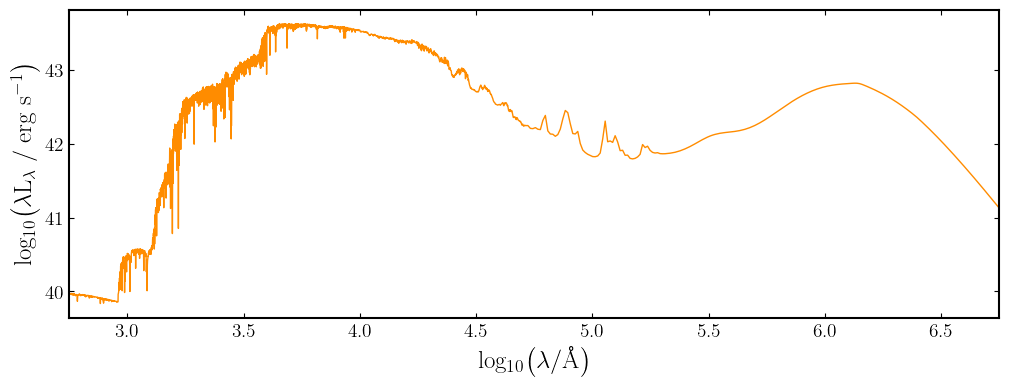

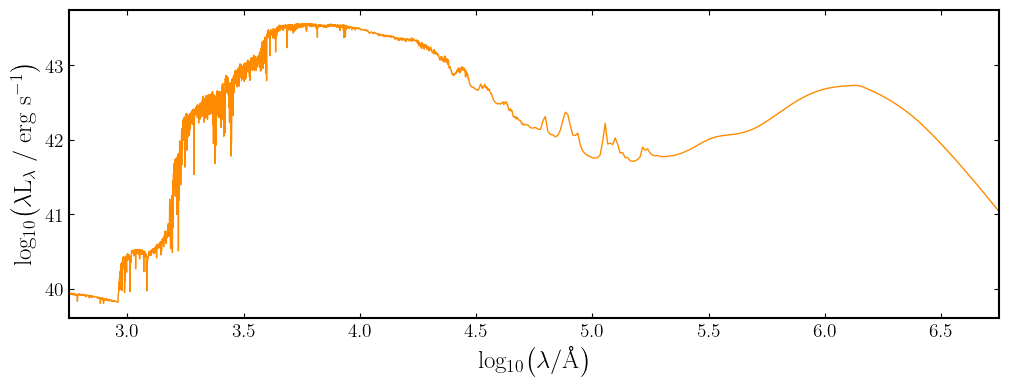

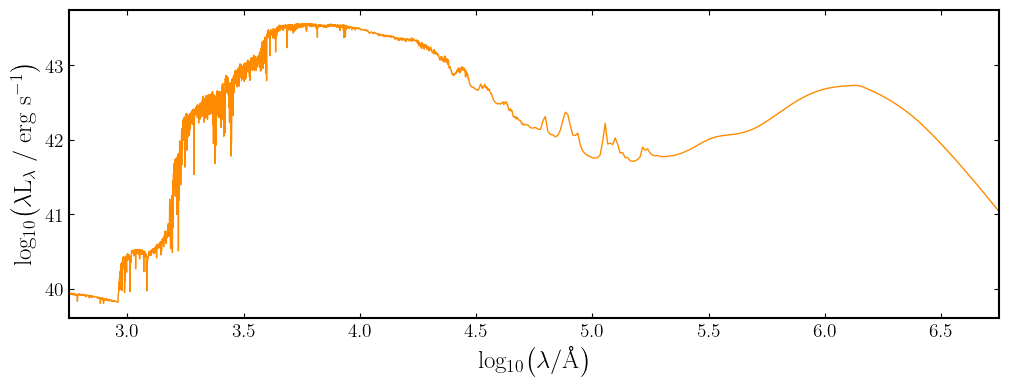

In [10]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

dust = {
    "type": "Calzetti",
    "Av": 0.2,
    "eta": 2.0
}

nebular = {
    "logU": -3.0
}

for t in ages_gyr:

    burst = {
        "age": t,            # Gyr
        "massformed": 10,
        "metallicity": 0.5
    }

    model_components = {
        "redshift": 0,
        "burst": burst,
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,        # Gyr
        "veldisp": 200.
    }

    model = pipes.model_galaxy(
        model_components,
        filt_list=filter_files,
        spec_wavs = np.arange(global_min - 500,
                      global_max + 500,
                      5.)

    )

    model.plot_full_spectrum()
    plt.show()


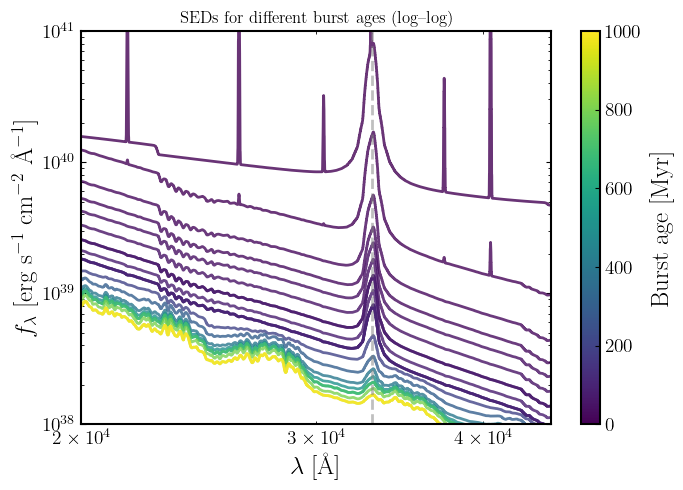

In [12]:
import pandas as pd
import matplotlib as mpl
import os

os.environ["PATH"] += r";C:\Users\Abigail Crowther\AppData\Local\Programs\MiKTeX\miktex\bin\x64"

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{amssymb}"
})

years = np.concatenate([
    np.arange(0, 110, 10),
    np.arange(100, 1100, 100)
])

fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

dust = {
    "type": "Calzetti",
    "Av": 0.2,
    "eta": 2.0
}

nebular = {
    "logU": -3.0
}

for t in years:

    burst = {
        "age": t / 1000,            # Gyr
        "massformed": 10,
        "metallicity": 0.5
    }

    model_components = {
        "redshift": 0,
        "burst": burst,
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,        # Gyr
        "veldisp": 200.
    }

    model = pipes.model_galaxy(
        model_components,
        filt_list=filter_files,
        spec_wavs = np.arange(global_min - 500,
                      global_max + 500,
                      5.)
    )

    ax.plot(
        model.spec_wavs,      # linear wavelength
        model.spectrum,       # linear flux
        color=cmap(norm(t)),
        alpha=0.8
    )

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$\lambda \; [\mathrm{\AA}]$")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]")
ax.set_ylim(1e38, 1e41)
ax.set_xlim(2e4, 4.5e4)
ax.axvline(3.3e4, color='grey', linestyle='--', alpha=0.5)
ax.set_title("SEDs for different burst ages (log–log)")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()


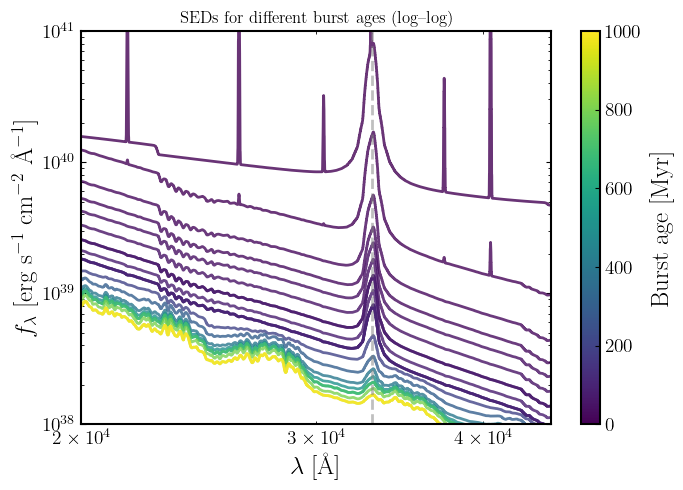

Saved: all_starburst_seds.csv


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bagpipes as pipes
import matplotlib as mpl
import os

os.environ["PATH"] += r";C:\Users\Abigail Crowther\AppData\Local\Programs\MiKTeX\miktex\bin\x64"

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{amssymb}"
})

years = np.concatenate([
    np.arange(0, 110, 10),
    np.arange(100, 1100, 100)
])

fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

dust = {
    "type": "Calzetti",
    "Av": 0.2,
    "eta": 2.0
}

nebular = {
    "logU": -3.0
}

spec_grid = np.arange(global_min - 500,
                      global_max + 500,
                      5.)

all_seds = {}
for t in years:

    burst = {
        "age": t / 1000.,   # convert Myr -> Gyr
        "massformed": 10,
        "metallicity": 0.5
    }

    model_components = {
        "redshift": 0,
        "burst": burst,
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,
        "veldisp": 200.
    }

    model = pipes.model_galaxy(
        model_components,
        filt_list=filter_files,
        spec_wavs=spec_grid
    )

    wave = model.spectrum[:, 0]
    flux = model.spectrum[:, 1]

    all_seds[t] = {
        "wavelength": wave,
        "flux": flux
    }

    ax.plot(
        wave,
        flux,
        color=cmap(norm(t)),
        alpha=0.8
    )

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$\lambda \; [\mathrm{\AA}]$")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]")

ax.set_ylim(1e38, 1e41)
ax.set_xlim(2e4, 4.5e4)

ax.axvline(3.3e4, color='grey', linestyle='--', alpha=0.5)
ax.set_title("SEDs for different burst ages (log–log)")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()

sed_df = pd.DataFrame({"wavelength_A": spec_grid})

for t in years:
    sed_df[f"flux_{int(t)}Myr"] = all_seds[t]["flux"]

sed_df.to_csv(r"D:\Users\Abigail Crowther\Desktop\Uni\Year 4\MPhys Projects\Semester 2 - Star Formation Histories\star-formation-histories\Data\all_starburst_seds.csv",
              sep="\t",
              index=False)

print("Saved: all_starburst_seds.csv")

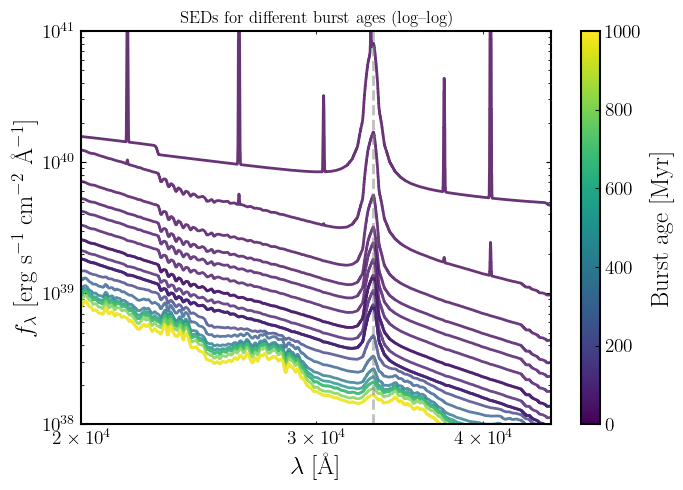

In [14]:
years = np.concatenate([
    np.arange(0, 110, 10),
    np.arange(100, 1100, 100)
])

fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

dust = {
    "type": "Calzetti",
    "Av": 0.2,
    "eta": 2.0
}

nebular = {
    "logU": -3.0
}

for t in years:

    burst = {
        "age": t / 1000,            # Gyr
        "massformed": 10,
        "metallicity": 0.5
    }

    model_components = {
        "redshift": 0,
        "burst": burst,
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,        # Gyr
        "veldisp": 200.
    }

    model = pipes.model_galaxy(
        model_components,
        filt_list=filter_files,
        spec_wavs = np.arange(global_min - 500,
                      global_max + 500,
                      5.)

    )

    ax.plot(
        model.spec_wavs,      # linear wavelength
        model.spectrum,       # linear flux
        color=cmap(norm(t)),
        alpha=0.8
    )

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$\lambda \; [\mathrm{\AA}]$")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]")
ax.set_ylim(1e38, 1e41)
ax.set_xlim(2e4, 4.5e4)
ax.axvline(3.308e4, color='grey', linestyle='--', alpha=0.5)
ax.set_title("SEDs for different burst ages (log–log)")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

years = np.concatenate([
    np.arange(0, 11, 1),
    np.arange(11, 110, 10),
    np.arange(110, 1100, 100)
])

#spectral diagnostic functions
def equivalent_width(wave, flux, line_region, blue_cont, red_cont):

    line_mask = (wave > line_region[0]) & (wave < line_region[1])
    blue_mask = (wave > blue_cont[0]) & (wave < blue_cont[1])
    red_mask  = (wave > red_cont[0]) & (wave < red_cont[1])

    cont_flux = np.mean(
        np.concatenate([flux[blue_mask], flux[red_mask]])
    )

    ew = np.trapz(1 - flux[line_mask] / cont_flux,
                  wave[line_mask])

    return ew


def d4000(wave, flux):

    blue = (wave > 3850.) & (wave < 3950.)
    red  = (wave > 4000.) & (wave < 4100.)

    return np.mean(flux[red]) / np.mean(flux[blue])

#Line windows
HDELTA_LINE = (4083., 4122.)
HDELTA_BLUE = (4041., 4079.)
HDELTA_RED  = (4128., 4161.)

HALPHA_LINE = (6553., 6573.)
HALPHA_BLUE = (6500., 6540.)
HALPHA_RED  = (6575., 6620.)

OII_LINE = (3720., 3735.)
OII_BLUE = (3650., 3700.)
OII_RED  = (3740., 3800.)

ew_hdelta_vals = []
ew_halpha_vals = []
ew_oii_vals = []
d4000_vals = []

for t in years:

    burst = {
        "age": t / 1000,            # Gyr
        "massformed": 10,
        "metallicity": 0.5
    }

    model_components = {
        "redshift": 0,
        "burst": burst,
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,        # Gyr
        "veldisp": 200.
    }

    model = pipes.model_galaxy(
        model_components,
        filt_list=filter_files,
        spec_wavs = np.arange(global_min - 500,
                      global_max + 500,
                      5.)

    )

    wave = model.spectrum[:, 0]
    flux = model.spectrum[:, 1]

    ew_hdelta = equivalent_width(
        wave, flux,
        HDELTA_LINE,
        HDELTA_BLUE,
        HDELTA_RED
    )

    ew_halpha = equivalent_width(
        wave, flux,
        HALPHA_LINE,
        HALPHA_BLUE,
        HALPHA_RED
    )

    ew_oii = equivalent_width(
        wave, flux,
        OII_LINE,
        OII_BLUE,
        OII_RED
    )
    d4 = d4000(wave, flux)

    ew_hdelta_vals.append(ew_hdelta)
    ew_halpha_vals.append(ew_halpha)
    ew_oii_vals.append(ew_oii)
    d4000_vals.append(d4)

print("\nSpectral diagnostics:\n")
for i, t in enumerate(years):
    print(f"Age = {t:.0f} Myr")
    print(f"  EW(Hδ)  = {ew_hdelta_vals[i]:.2f} Å")
    print(f"  EW(Hα)  = {ew_halpha_vals[i]:.2f} Å")
    print(f"  EW([O II]) = {ew_oii_vals[i]:.2f} Å")
    print(f"  D4000   = {d4000_vals[i]:.2f}")
    print()

results_df = pd.DataFrame({
    "Age_Myr": years,
    "EW_Hdelta_A": ew_hdelta_vals,
    "EW_Halpha_A": ew_halpha_vals,
    "EW_OII_A": ew_oii_vals,
    "D4000": d4000_vals
})

results_df.to_csv(r"D:\Users\Abigail Crowther\Desktop\Uni\Year 4\MPhys Projects\Semester 2 - Star Formation Histories\star-formation-histories\Data\spectral_ew_d4000.csv", index=False)
print("Saved as csv!")


Spectral diagnostics:

Age = 0 Myr
  EW(Hδ)  = -63.73 Å
  EW(Hα)  = -314.75 Å
  EW([O II]) = -868.87 Å
  D4000   = 0.49

Age = 1 Myr
  EW(Hδ)  = -63.73 Å
  EW(Hα)  = -314.75 Å
  EW([O II]) = -868.87 Å
  D4000   = 0.49

Age = 2 Myr
  EW(Hδ)  = -58.30 Å
  EW(Hα)  = -308.80 Å
  EW([O II]) = -797.05 Å
  D4000   = 0.61

Age = 3 Myr
  EW(Hδ)  = -35.76 Å
  EW(Hα)  = -324.54 Å
  EW([O II]) = -404.26 Å
  D4000   = 0.62

Age = 4 Myr
  EW(Hδ)  = -21.20 Å
  EW(Hα)  = -310.42 Å
  EW([O II]) = -233.27 Å
  D4000   = 0.65

Age = 5 Myr
  EW(Hδ)  = -10.07 Å
  EW(Hα)  = -238.60 Å
  EW([O II]) = -128.42 Å
  D4000   = 0.79

Age = 6 Myr
  EW(Hδ)  = -2.26 Å
  EW(Hα)  = -118.31 Å
  EW([O II]) = -65.16 Å
  D4000   = 0.95

Age = 7 Myr
  EW(Hδ)  = -2.26 Å
  EW(Hα)  = -118.31 Å
  EW([O II]) = -65.16 Å
  D4000   = 0.95

Age = 8 Myr
  EW(Hδ)  = 0.74 Å
  EW(Hα)  = -59.64 Å
  EW([O II]) = -24.00 Å
  D4000   = 0.99

Age = 9 Myr
  EW(Hδ)  = 3.67 Å
  EW(Hα)  = -14.00 Å
  EW([O II]) = -3.50 Å
  D4000   = 0.96

Age = 10 

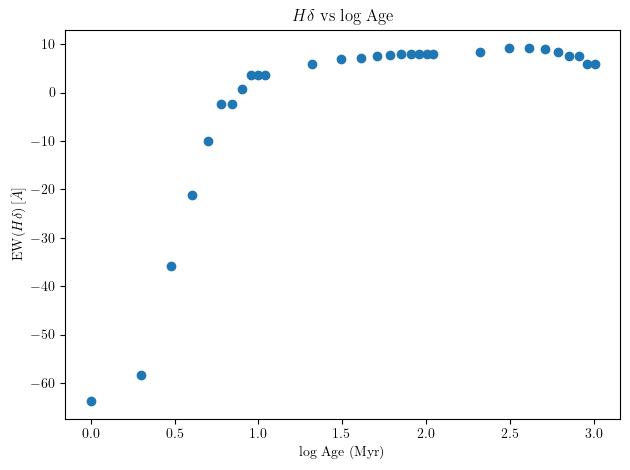

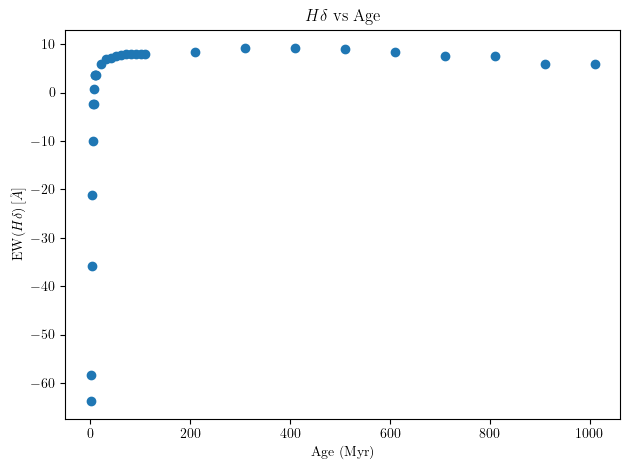

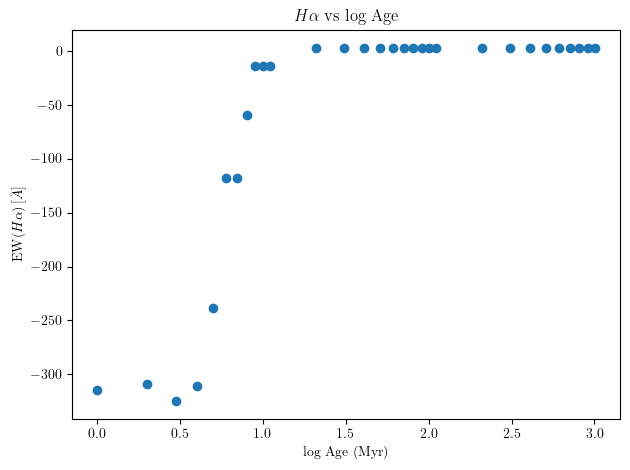

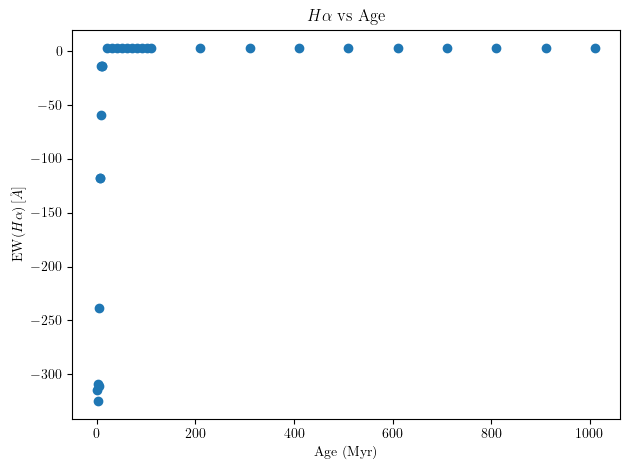

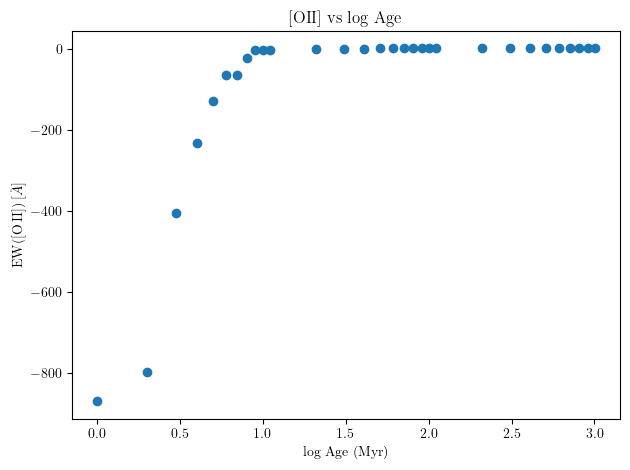

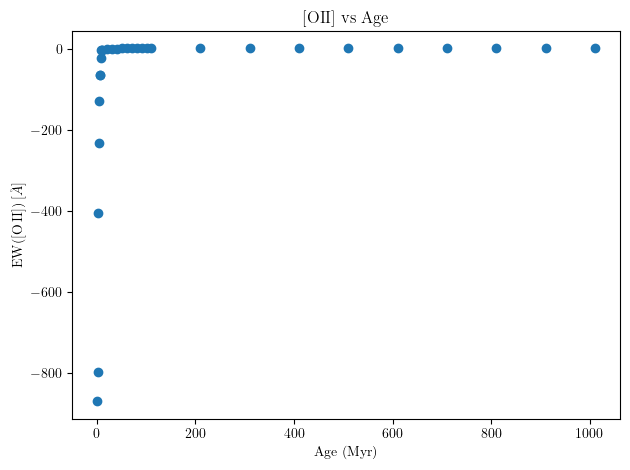

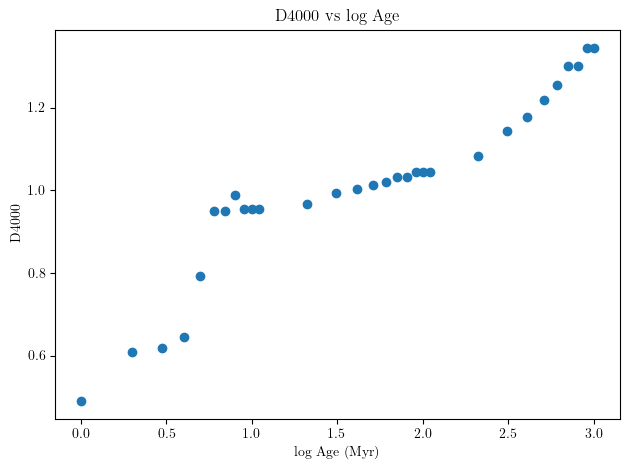

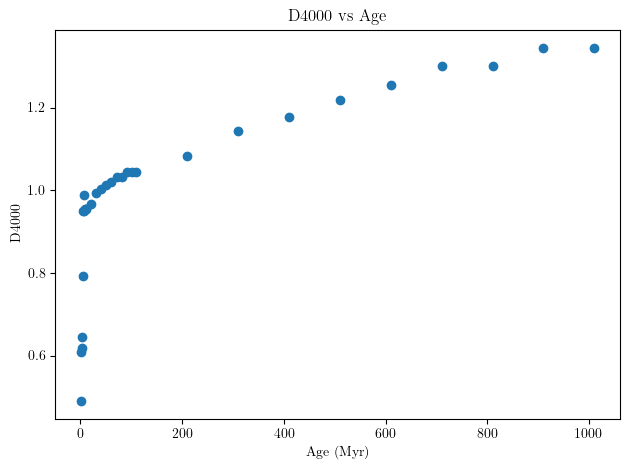

In [2]:
#including 0-10 Myr in 1 Myr intervals
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
import os

os.environ["PATH"] += r";C:\Users\Abigail Crowther\AppData\Local\Programs\MiKTeX\miktex\bin\x64"

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{amssymb}"
})

df = pd.read_csv(r"D:\Users\Abigail Crowther\Desktop\Uni\Year 4\MPhys Projects\Semester 2 - Star Formation Histories\star-formation-histories\Data\spectral_ew_d4000.csv")

age_myr = df["Age_Myr"].values
ew_hdelta = df["EW_Hdelta_A"].values
ew_halpha = df["EW_Halpha_A"].values
ew_oii = df["EW_OII_A"].values
d4000 = df["D4000"].values

mask = age_myr > 0
log_age = np.log10(age_myr[mask])

#Plot EW(Hδ)
plt.figure()
plt.scatter(log_age, ew_hdelta[mask], marker='o')
plt.xlabel("log Age (Myr)")
plt.ylabel(r"$\mathrm{EW}(H\delta)\,[\AA]$")
plt.title(r"$H\delta$ vs log Age")
plt.tight_layout()
plt.show()

plt.figure()
plt.scatter(age_myr[mask], ew_hdelta[mask], marker='o')
plt.xlabel("Age (Myr)")
plt.ylabel(r"$\mathrm{EW}(H\delta)\,[\AA]$")
plt.title(r"$H\delta$ vs Age")
plt.tight_layout()
plt.show()

#Plot EW(Hα)
plt.figure()
plt.scatter(log_age, ew_halpha[mask], marker='o')
plt.xlabel("log Age (Myr)")
plt.ylabel(r"$\mathrm{EW}(H\alpha)\,[\AA]$")
plt.title(r"$H\alpha$ vs log Age")
plt.tight_layout()
plt.show()

plt.figure()
plt.scatter(age_myr[mask], ew_halpha[mask], marker='o')
plt.xlabel("Age (Myr)")
plt.ylabel(r"$\mathrm{EW}(H\alpha)\,[\AA]$")
plt.title(r"$H\alpha$ vs Age")
plt.tight_layout()
plt.show()

#Plot EW([O II])
plt.figure()
plt.scatter(log_age, ew_oii[mask], marker='o')
plt.xlabel("log Age (Myr)")
plt.ylabel(r"$\mathrm{EW}([\mathrm{O\,II}])\,[\AA]$")
plt.title("[OII] vs log Age")
plt.tight_layout()
plt.show()

plt.figure()
plt.scatter(age_myr[mask], ew_oii[mask], marker='o')
plt.xlabel("Age (Myr)")
plt.ylabel(r"$\mathrm{EW}([\mathrm{O\,II}])\,[\AA]$")
plt.title("[OII] vs Age")
plt.tight_layout()
plt.show()

#Plot D4000
plt.figure()
plt.scatter(log_age, d4000[mask], marker='o')
plt.xlabel("log Age (Myr)")
plt.ylabel("D4000")
plt.title("D4000 vs log Age")
plt.tight_layout()
plt.show()

plt.figure()
plt.scatter(age_myr[mask], d4000[mask], marker='o')
plt.xlabel("Age (Myr)")
plt.ylabel("D4000")
plt.title("D4000 vs Age")
plt.tight_layout()
plt.show()